## SimpleRNN - Results Summary

- **Model:** SimpleRNN (two stacked layers)
- **Vocabulary size:** 50,000
- **Max sequence length:** 50
- **Embedding dim:** 128
- **Class weights:** balanced
- **Preprocessing:** lowercase, remove URLs, remove emojis

**Three architectures compared:**
- V1: hidden_size1=128, hidden_size2=64, Dropout(0.5)
- V2: hidden_size1=64,  hidden_size2=32, Dropout(0.5)
- V3: hidden_size1=64,  hidden_size2=32, no Dropout   - selected

**Overall Test Results:**
- V3 (selected):  Macro F1 0.69  |  Accuracy 0.69
- V1:             Macro F1 0.67  |  Accuracy 0.67
- V2:             Macro F1 0.61  |  Accuracy 0.62

**Per-Language Results (V3 — selected):**
- Hausa  achieved a Macro F1 of 0.72 — beat LogReg (0.71 → 0.72)  ← improved
- Igbo   achieved a Macro F1 of 0.74 — beat LogReg (0.73 → 0.74)
- Pidgin achieved a Macro F1 of 0.38 — still the worst (Pidgin neutral F1: 0.08)
- Yoruba achieved a Macro F1 of 0.67 — marginal drop vs LogReg (0.68 → 0.67)

**Key Findings:**
- V3 matched the LogReg baseline overall (0.69 vs 0.69)
- V3 beat LogReg on Hausa and Igbo — sequential context helps cleaner languages
- V2 collapsed this run (F1 0.61) due to random initialisation — confirms
  Dropout(0.5) makes the small architecture unstable across runs
- V3 without dropout is consistent across runs — the correct architecture choice
- Negative class over-predicted across all languages, worst in Pidgin (recall 0.93)
- Pidgin neutral near-zero (F1: 0.08) — data shortage, not model problem

**vs Logistic Regression Baseline:**
- Overall Macro F1:  0.69 vs 0.69  - tied
- Hausa  F1:  0.72 vs 0.71         - RNN leads 
- Igbo   F1:  0.74 vs 0.73         - RNN leads 
- Pidgin F1:  0.38 vs 0.44         - LogReg leads
- Yoruba F1:  0.67 vs 0.68         - LogReg leads (marginal)

**SimpleRNN matched LogReg overall and beat it on two languages. LSTM's
gated memory should push the remaining languages above the baseline.**

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import re
import pickle

import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# load the datasets
df_train = pd.read_csv('../01-data/02-processed/train_clean.csv')
df_test = pd.read_csv('../01-data/02-processed/test_clean.csv')
df_val = pd.read_csv('../01-data/02-processed/val_clean.csv')

In [3]:
def dataset_preprocessing(text):
    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
    )

    text = emoji_pattern.sub('', text)

    return text.strip()

In [4]:
# drop tweet length from train dataset
df_train.drop(columns=['tweet_length'], inplace=True)

df_list = [df_train, df_test, df_val]
for df in df_list:
    df['cleaned_tweet'] = df['tweet'].apply(dataset_preprocessing)
    df.drop(columns=['tweet'], inplace=True)
    df.rename(columns={'cleaned_tweet': 'tweet'}, inplace=True)

In [5]:
# split dataset for training, validation and testing
X_train = df_train['tweet']
y_train = df_train['label']
X_test = df_test['tweet']
y_test = df_test['label']
X_val = df_val['tweet']
y_val = df_val['label']

In [6]:
def preparation_for_model_train(X_train, X_val, X_test,
                                 y_train, y_val, y_test,
                                 vocab_size=50000, max_len=50):

    tokenizer = Tokenizer(num_words=vocab_size)

    tokenizer.fit_on_texts(X_train)

    # convert text to numbers

    X_train_seq = tokenizer.texts_to_sequences(X_train)

    X_val_seq = tokenizer.texts_to_sequences(X_val)

    X_test_seq = tokenizer.texts_to_sequences(X_test)

    # pad the sequences because RNN requires the same input size
    # we will choose 50 as the max length as prosposed during the eda process


    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)

    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)

    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

    label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}

    y_train = y_train.map(label_mapping).values

    y_val   = y_val.map(label_mapping).values

    y_test = y_test.map(label_mapping).values

    return X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, tokenizer

In [7]:
X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, tokenizer = preparation_for_model_train(
    X_train, X_val, X_test, y_train, y_val, y_test, vocab_size = 50000, max_len= 50
)

In [8]:
def build_simple_rnn_model(
        vocab_size=50000,
        embedding_dim=128,
        hidden_size1=128,
        hidden_size2=64,
        dropout_rate=0.5
):
    model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
        ),

    SimpleRNN(
        units=hidden_size1,
        return_sequences=True
        ),

    Dropout(dropout_rate),

    SimpleRNN(hidden_size2),
    
    Dropout(dropout_rate),

    Dense(3, activation="softmax")

    ])

    # compile the model
    model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return model

### Model V1

- Vocabulary size: 50,000
- Embedding dimension: 128
- RNN Layer 1: 128 units (return_sequences=True)
- RNN Layer 2: 64 units
- Dropout rate: 0.5
- Output layer: 3 units (softmax activation)

In [9]:
model_rnn_v1 = build_simple_rnn_model()

In [10]:
# compute and add class weights because of the limited 
# representation of the neutral sentiment for pidgin class
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(enumerate(weights))

# Early stopping is defined once and reused across all three model fits.
# This is intentional — EarlyStopping resets its internal state at the
# start of each model.fit() call, so there is no build early stopping again between models.
# patience=3 and restore_best_weights=True apply fresh to each run.

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=3,            # wait 3 epochs before stopping
    restore_best_weights=True  # roll back to best epoch weights
)

# Then in model.fit:
history = model_rnn_v1.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 85s 69ms/step - accuracy: 0.5526 - loss: 0.9311 - val_accuracy: 0.6894 - val_loss: 0.7235
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 96s 82ms/step - accuracy: 0.7714 - loss: 0.5780 - val_accuracy: 0.7042 - val_loss: 0.7292
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 76s 67ms/step - accuracy: 0.8888 - loss: 0.3079 - val_accuracy: 0.6922 - val_loss: 0.9010
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 85s 69ms/step - accuracy: 0.9459 - loss: 0.1587 - val_accuracy: 0.6704 - val_loss: 1.1818


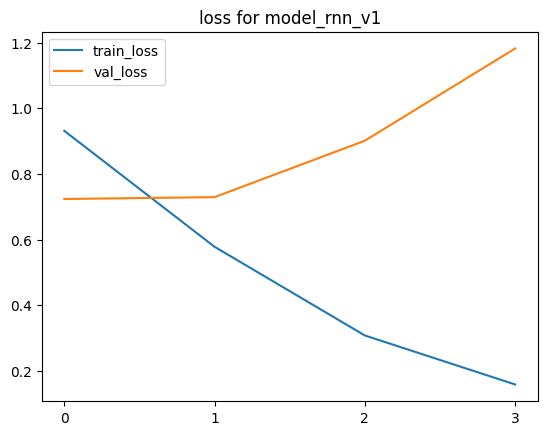

In [11]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v1")
plt.legend()
plt.show()

In [12]:
predict = model_rnn_v1.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v1: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v1')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step


f1_macro_v1: 0.6688365628481657
CLASSIFICATION REPORT FOR model_rnn_v1
              precision    recall  f1-score   support

    negative       0.65      0.60      0.62      6009
     neutral       0.62      0.75      0.68      5457
    positive       0.76      0.66      0.71      6188

    accuracy                           0.67     17654
   macro avg       0.67      0.67      0.67     17654
weighted avg       0.68      0.67      0.67     17654



### Model V2

- Vocabulary size: 50,000
- Embedding dimension: 128
- RNN Layer 1: 64 units (return_sequences=True)
- RNN Layer 2: 32 units
- Dropout rate: 0.5
- Output layer: 3 units (softmax activation)

In [13]:
model_rnn_v2 = build_simple_rnn_model(hidden_size1=64, hidden_size2=32)

# Then in model.fit:
history = model_rnn_v2.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 74s 61ms/step - accuracy: 0.5655 - loss: 0.9109 - val_accuracy: 0.6544 - val_loss: 0.7628
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.7850 - loss: 0.5550 - val_accuracy: 0.7018 - val_loss: 0.7261
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 61s 54ms/step - accuracy: 0.8999 - loss: 0.2815 - val_accuracy: 0.7060 - val_loss: 0.9192


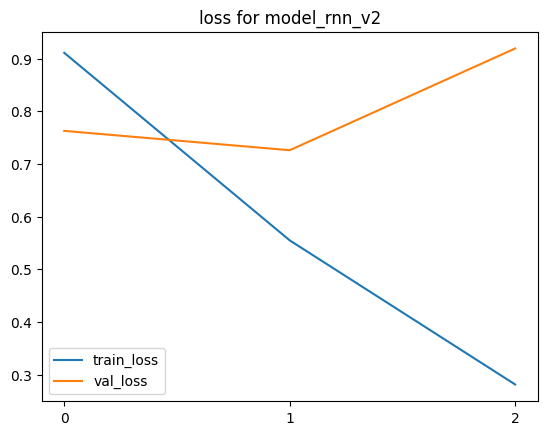

In [14]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v2")
plt.legend()
plt.show()

In [15]:
predict = model_rnn_v2.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v2: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v2')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step


f1_macro_v2: 0.6111063418346477
CLASSIFICATION REPORT FOR model_rnn_v2
              precision    recall  f1-score   support

    negative       0.51      0.84      0.63      6009
     neutral       0.69      0.44      0.54      5457
    positive       0.81      0.56      0.66      6188

    accuracy                           0.62     17654
   macro avg       0.67      0.61      0.61     17654
weighted avg       0.67      0.62      0.61     17654



### Model V3

- Vocabulary size: 50,000
- Embedding layer: 128-dimensional word representations (mask_zero=True)
- RNN Layer 1: 64 units (return_sequences=True)
- RNN Layer 2: 32 units
- Dropout: None
- Output layer: 3 units (softmax activation)

In [16]:
def build_simple_rnn_model_v3(vocab_size=50000, embedding_dim=128,
                               hidden_size1=64, hidden_size2=32):
    # V3 differs from V1/V2 in two ways:
    # 1. No Dropout — removed because Dropout(0.5) was too aggressive
    #    for the small 64→32 architecture, hurting more than helping
    # 2. mask_zero=True in Embedding — tells the model to ignore
    #    padding tokens (0s) during training, which V1/V2 did not do
    
    model = Sequential([
        Embedding(vocab_size, embedding_dim, mask_zero=True),
        SimpleRNN(hidden_size1, return_sequences=True),
        SimpleRNN(hidden_size2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [17]:
model_rnn_v3 = build_simple_rnn_model_v3()

# Then in model.fit:
history = model_rnn_v3.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 76s 63ms/step - accuracy: 0.6525 - loss: 0.7711 - val_accuracy: 0.7192 - val_loss: 0.6659
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 87s 76ms/step - accuracy: 0.8669 - loss: 0.3496 - val_accuracy: 0.7052 - val_loss: 0.7890
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 133s 68ms/step - accuracy: 0.9628 - loss: 0.1099 - val_accuracy: 0.6867 - val_loss: 1.1098
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 90s 78ms/step - accuracy: 0.9838 - loss: 0.0493 - val_accuracy: 0.6875 - val_loss: 1.3586


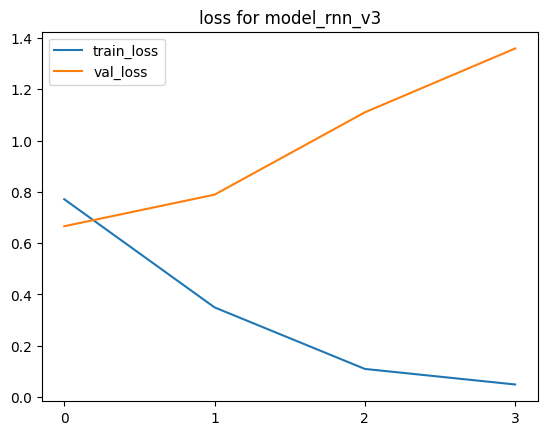

In [18]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v3")
plt.legend()
plt.show()

In [19]:
predict = model_rnn_v3.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v3: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v3')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


f1_macro_v3: 0.6888230033951285
CLASSIFICATION REPORT FOR model_rnn_v3
              precision    recall  f1-score   support

    negative       0.62      0.77      0.69      6009
     neutral       0.69      0.66      0.67      5457
    positive       0.79      0.63      0.70      6188

    accuracy                           0.69     17654
   macro avg       0.70      0.69      0.69     17654
weighted avg       0.70      0.69      0.69     17654



In [20]:
reverse_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
predict = model_rnn_v3.predict(X_test_pad)
y_pred = np.argmax(predict, axis=1)
df_test['predicted'] = y_pred
df_test['predicted'] = df_test['predicted'].map(reverse_mapping)

for lang in ['hausa', 'igbo', 'pidgin', 'yoruba']:
    subset = df_test[df_test['language'] == lang]
    print(f"\n{'='*50}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*50}")
    print(classification_report(subset['label'], subset['predicted'],
                                target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step

Language: HAUSA
              precision    recall  f1-score   support

    negative       0.67      0.70      0.68      1759
     neutral       0.67      0.67      0.67      1789
    positive       0.83      0.77      0.80      1755

    accuracy                           0.72      5303
   macro avg       0.72      0.72      0.72      5303
weighted avg       0.72      0.72      0.72      5303


Language: IGBO
              precision    recall  f1-score   support

    negative       0.71      0.67      0.69       943
     neutral       0.74      0.79      0.76      1621
    positive       0.81      0.76      0.78      1118

    accuracy                           0.75      3682
   macro avg       0.75      0.74      0.74      3682
weighted avg       0.75      0.75      0.75      3682


Language: PIDGIN
              precision    recall  f1-score   support

    negative       0.61      0.93      0.74      2326
     neutral       0.23      0.05   

In [21]:
# save the selected model (V3) to the models folder
model_rnn_v3.save('../03-models/rnn_v3.keras')
print("model saved to 03-models/rnn_v3.keras")

model saved to 03-models/rnn_v3.keras


In [22]:
# save the tokenizer — needed for LSTM and any future inference

with open('../03-models/rnn_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("tokenizer saved to 03-models/rnn_tokenizer.pkl")

tokenizer saved to 03-models/rnn_tokenizer.pkl
